In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
import sys
from IPython.display import Image
import seaborn
import pandas as pd
import itertools
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.metrics import r2_score
from multipledispatch import dispatch

seaborn.set_theme(style="whitegrid")

seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080']
palette = itertools.cycle(seaborn.color_palette(palette=zesty))

src_dir = os.path.abspath("/home/mmfarrugia/repos/q2mm")
sys.path.append(src_dir)
#sys.path.append("/home/mfarrugi/repos/q2mm/rh-hybrid/schrodinger.ve/lib/python3.11/site-packages/q2mm-0.0.0-py3.11.egg")


from tools.ff_plotting import *

**Rhodium-catalyzed Hydrogenation of Enamides TSFF Parameterized via FUERZA Projections & Subsequent Gradient Optimization**

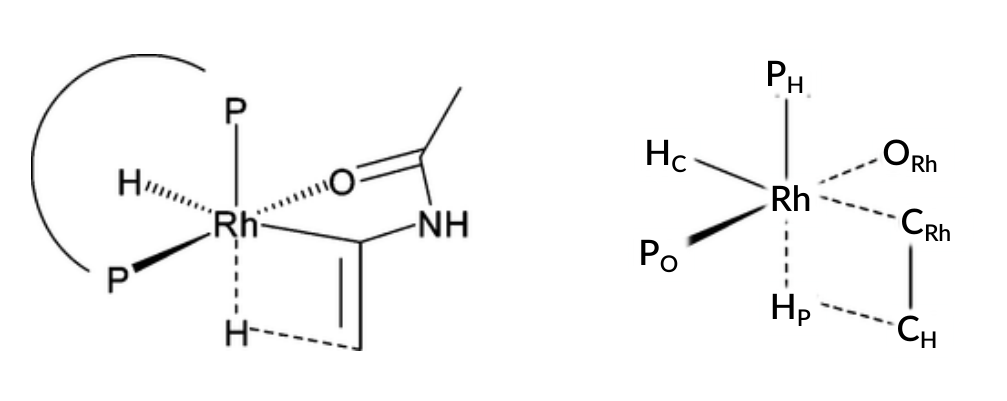

In [3]:
Image(filename='/home/mfarrugi/Documents/Rh_figures/rh_system_defn.png')

In [ ]:
bond_cols = ["param_type", "atom1", "atom2", "Equilibrium Value", "Force Constant", "Dipole Moment", "FF"]
angle_cols = ["param_type", "atom1", "atom2", "atom3", "Equilibrium Value", "Force Constant", "FF"]
score_cols = ["Label", "Weight", "Reference", "Calculated", "Score", "FF"]
skiprows=[0, 1, 106390, 106391, 106392, 106393, 106394, 106395, 106396, 106397, 106398, 106399, 106400, 106401]
bond_rows = np.arange(1859, 1867)
angle_rows = np.concatenate((np.arange(1867, 1889), [1908]))
bonds_rows = [str(bond_row+1) for bond_row in bond_rows]
angles_rows = [str(angle_row+1) for angle_row in angle_rows]
ff_rows = np.concatenate((bond_rows, angle_rows))
ffs_rows = [str(ff_row + 1) for ff_row in ff_rows]
rows = [*bond_rows, *angle_rows]
convergence_criteria = 0.001
num_params = 31
substructure_strings = ['HX-RH(-PX)-HX.C2*C2(.2)-N2-C2=O2.2', 'RH-PX']
param_names = ['Hc-Rh', 'Rh-P\u2095', 'Rh-P\u2092', 'Rh-H\u209A', 'Rh.CRh', 'Rh.ORh', 'H\u209A.C\u2095', 'C\u2095*CRh', 'Hc-Rh-P\u2095', 'Hc-Rh-P\u2092', 'Hc-Rh-H\u209A', 'Hc-Rh.CRh', 'Hc-Rh.ORh', 'P\u2095-Rh-H\u209A', 'P\u2092-Rh-H\u209A', 'P\u2095-Rh.CRh', 'P\u2092-Rh.CRh', 'P\u2095-Rh.ORh','P\u2092-Rh.ORh', 'H\u209A-Rh.CRh', 'H\u209A-Rh.ORh', 'CRh.Rh.ORh', 'Rh-H\u209A.C\u2095', 'H\u209A.C\u2095*00', 'CRh*C\u2095.H\u209A', 'Rh.CRh*C0', 'Rh.CRh*C2o', 'Rh.CRh*C\u2095', 'Rh.CRh-N2', 'Rh.ORh=C2', 'P\u209A-Rh-P\u2095']
bond_label_list = param_names[:8]
angle_label_list = param_names[8:]

base_direc = os.getcwd()

# Scores

## unoptimized data
static_score = 2.67645
static_scores = pd.read_csv('q_static/rh_qstatic_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Approxn: '+str(static_score))
fuerza_score = 1.36077746
fuerza_scores = pd.read_csv('q_fuerza/rh_qf_grad_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(fuerza_score))
gamma_fuerza_score = 247.7877
gamma_fuerza_scores = pd.read_csv('gamma_q_fuerza/eig_gamma.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=r'$\mathit{\gamma}$-FUERZA: '+str(gamma_fuerza_score))
ffuerza_score = 107.7652
ffuerza_scores = pd.read_csv('q_frankenfuerza/eig_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FFUERZA: '+str(ffuerza_score))
donoghue_score = 3.4894
donoghue_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/rh_donoghue_final_scores.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_score)

## optimized data
normal_grad_score = 1.7479
normal_grad_scores = pd.read_csv('q_static/score.static.grad.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Approxn-GRAD: '+str(normal_grad_score))
fuerza_grad_score = 1.747901
fuerza_grad_scores = pd.read_csv('q_fuerza/rh_qf_grad_end.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA-GRAD: '+str(fuerza_grad_score))
gamma_fuerza_grad_score = 1.7482
gamma_fuerza_grad_scores = pd.read_csv('gamma_q_fuerza/score.gamma.grad.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=r'$\mathit{\gamma}$-FUERZA-GRAD: '+str(gamma_fuerza_grad_score))
ffuerza_grad_score = 1.7479001
ffuerza_grad_scores = pd.read_csv('q_frankenfuerza/score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FFUERZA-GRAD: '+str(ffuerza_grad_score))
donoghue_grad_score = 3.4894
donoghue_grad_scores = pd.read_csv('donoghue/rh_donoghue_final_scores.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_score)
fuerza_grad_score = 1.747901
fuerza_grad_scores = pd.read_csv('uninv_q_fuerza/score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA-GRAD: '+str(fuerza_grad_score))

# Bonds

## unoptimized
bond_normal = pd.read_csv('q_static/mm3.static.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=static_score)
angle_normal = pd.read_csv('q_static/mm3.static.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=static_score)
bond_fuerza, angle_fuerza, param_fuerza = get_ff_params(base_direc, ['q_fuerza'], 'rh_hyd_enamide_q_seminario.fld', [fuerza_score], bond_rows, angle_rows, 'FUERZA')
bond_fuerza = bond_fuerza[0]
angle_fuerza = angle_fuerza[0]
bond_gamma_fuerza, gamma_angle_fuerza, param_gamma_fuerza = get_ff_params(base_direc, ['gamma_q_fuerza'], 'cisplatin_gamma_fuerza.fld', [gamma_fuerza_score], bond_rows, angle_rows, r'$\mathit{\gamma}$-FUERZA')
gamma_angle_fuerza = gamma_angle_fuerza[0]
bond_ffuerza, angle_ffuerza, param_ffuerza = get_ff_params('frankenfuerza', [''], 'q_frankenfuerza_H.fld', [ffuerza_score], bond_rows, angle_rows, 'FFUERZA')
angle_ffuerza = angle_ffuerza[0]
bond_don = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/ff/rh_hyd_enamide_final.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=donoghue_score)
angle_don = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/ff/rh_hyd_enamide_final.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=donoghue_score)
bond_don = bond_don.assign(ff_row=bonds_rows).assign(atom3='-')
angle_don = angle_don.assign(ff_row=angles_rows)
params_don = pd.concat([bond_don, angle_don])
melted_params_don = pd.melt(params_don, id_vars=['param_type', 'atom1', 'atom2', 'atom3', 'ff_row'], value_vars=['Force Constant'])

## optimized
bond_normal_grad = pd.read_csv('q_static/mm3.static.grad.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=normal_grad_score)
angle_normal_grad = pd.read_csv('q_static/mm3.static.grad.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=normal_grad_score)
bond_fuerza_grad = pd.read_csv('q_fuerza/rh_qf_grad_end.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=fuerza_grad_score)
angle_fuerza_grad = pd.read_csv('q_fuerza/rh_qf_grad_end.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=fuerza_grad_score)
gamma_bond_fuerza_grad = pd.read_csv('gamma_q_fuerza/mm3.gamma.grad.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=gamma_fuerza_score)
gamma_angle_fuerza_grad = pd.read_csv('gamma_q_fuerza/mm3.gamma.grad.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=gamma_fuerza_score)
bond_ffuerza_grad = pd.read_csv('q_frankenfuerza/mm3.eig.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=ffuerza_grad_score)
angle_ffuerza_grad = pd.read_csv('q_frankenfuerza/mm3.eig.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=ffuerza_grad_score)

bonds = [bond_fuerza, bond_fuerza, bond_fuerza, bond_normal_grad, bond_fuerza_grad, gamma_bond_fuerza_grad, bond_ffuerza_grad]
angles = [angle_fuerza, gamma_angle_fuerza, angle_ffuerza, angle_normal_grad, angle_fuerza_grad, angle_ffuerza_grad, gamma_angle_fuerza_grad]
eigenmatrix_scores = [static_scores, fuerza_scores, gamma_fuerza_scores, ffuerza_scores, normal_grad_scores, fuerza_grad_scores, gamma_fuerza_grad_scores, ffuerza_grad_scores]
score_sums = ['Approxn: '+'{0:.3f}'.format(static_score), 'FUERZA: '+'{0:.3f}'.format(fuerza_score), r'$\mathit{\gamma}$-FUERZA: '+'{0:.3f}'.format(gamma_fuerza_score), 'FFUERZA: '+'{0:.3f}'.format(ffuerza_score), 'Approxn-GRAD: '+'{0:.3f}'.format(normal_grad_score), 'FUERZA-GRAD: '+'{0:.3f}'.format(fuerza_grad_score), r'$\mathit{\gamma}$-FUERZA-GRAD: '+'{0:.3f}'.format(gamma_fuerza_grad_score), 'FFUERZA-GRAD: '+'{0:.3f}'.format(ffuerza_grad_score)]

In [3]:
def style_per_plot_legends(axes:list):# -> list:
    for ax in axes:
        ax.legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=1., handletextpad=0.)
    return axes

@dispatch(list)
def style_fig_legend(axes:list):
    for ax in axes:
        ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)
    return axes

@dispatch(plt.Axes)
def style_fig_legend(axes:plt.Axes):
    ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)
    return ax

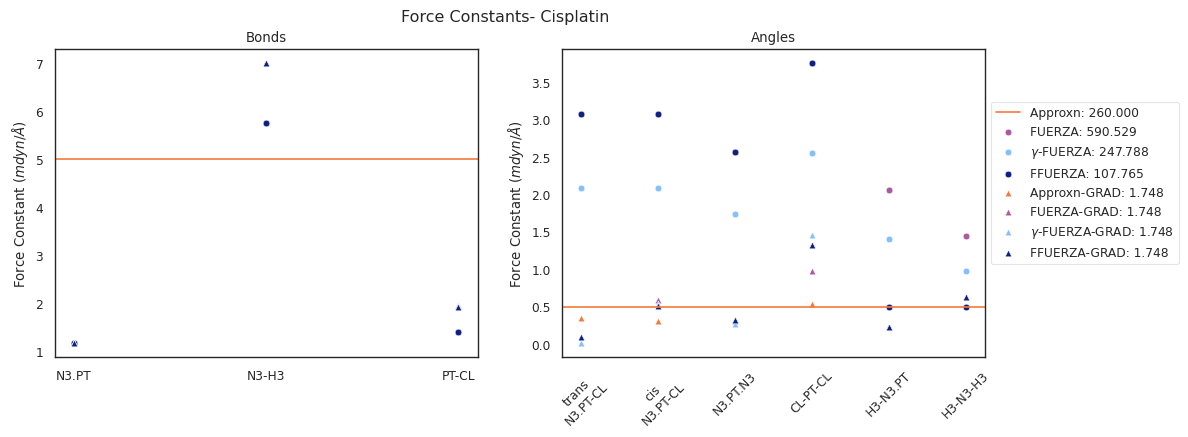

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Bonds'}, ylabel='Force Constant ($mdyn/\\AA$)'>,
        <Axes: title={'center': 'Angles'}, ylabel='Force Constant ($mdyn/\\AA$)'>],
       dtype=object))

In [4]:
plot_ff_params_v_static(bonds, angles, score_sums[1:], bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=score_sums[0], title='- Cisplatin')

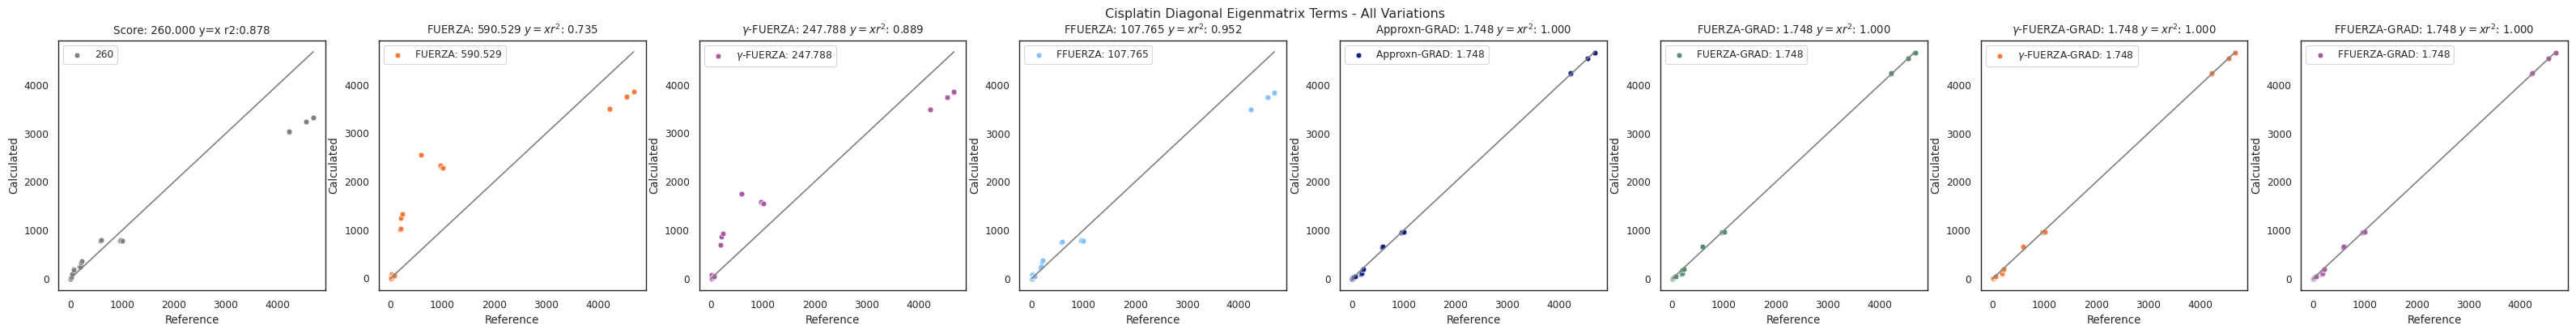

In [5]:
linear_fit_diag_scores(static_scores, static_score, eigenmatrix_scores[1:], score_sums[1:], ' Cisplatin Diagonal Eigenmatrix Terms - All Variations')

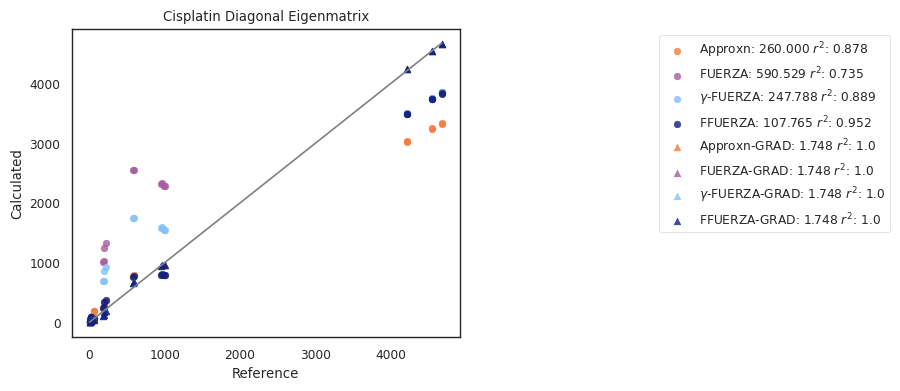

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(5,4))
ax.set_title('Cisplatin Diagonal Eigenmatrix')
palette = itertools.cycle(seaborn.color_palette(palette=zesty))
palette_opt = itertools.cycle(seaborn.color_palette(palette=zesty))


for eigenmatrix, score in zip(eigenmatrix_scores, score_sums):
    diag = eigenmatrix.loc[eigenmatrix['Reference'] != 0.0000]
    diag = diag.loc[diag['Weight'] != 0.0000]
    #slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
    r2_ = r2_score(diag['Reference'], diag['Calculated'])
    if any(opt_flag in score for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
        marker="^"
        color = next(palette_opt)
    else:
        marker = "o"
        color = next(palette)
    seaborn.scatterplot(data=diag, y='Calculated', x='Reference', color=color, edgecolor=color, label=score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)), ax=ax, marker=marker, alpha = 0.8)

seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax)
ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)

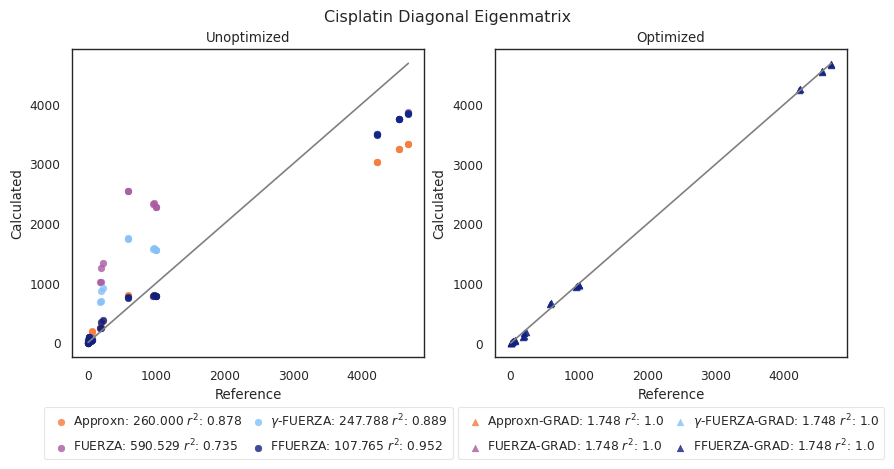

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Cisplatin Diagonal Eigenmatrix')
palette = itertools.cycle(seaborn.color_palette(palette=zesty))
palette_opt = itertools.cycle(seaborn.color_palette(palette=zesty))

r2_scores = []
r2_score_labels = []

for eigenmatrix, score in zip(eigenmatrix_scores, score_sums):
    diag = eigenmatrix.loc[eigenmatrix['Reference'] != 0.0000]
    diag = diag.loc[diag['Weight'] != 0.0000]
    #slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
    r2_ = r2_score(diag['Reference'], diag['Calculated'])
    r2_scores.append(r2_)
    if any(opt_flag in score for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
        marker="^"
        color = next(palette_opt)
        axis=1
    else:
        marker = "o"
        color = next(palette)
        axis=0
    seaborn.scatterplot(data=diag, y='Calculated', x='Reference', color=color, edgecolor=color, label=score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)), ax=ax[axis], marker=marker, alpha = 0.8)
    r2_score_labels.append(score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)))

seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[0])
seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[1])
ax[0].set_title('Unoptimized')
ax[1].set_title('Optimized')
ax[0].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)
ax[1].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)

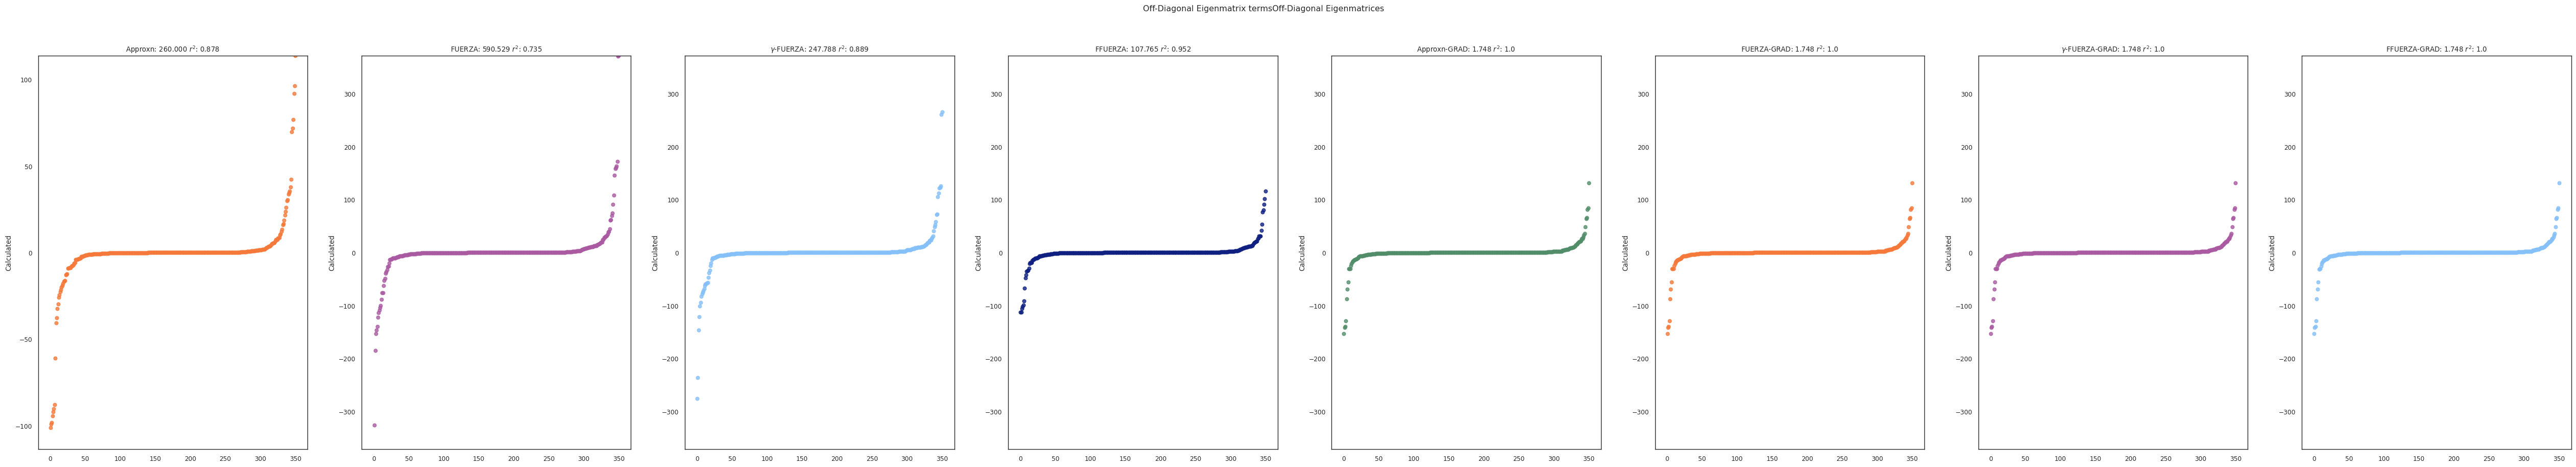

In [8]:
plot_off_diag_scatter(eigenmatrix_scores, r2_score_labels, 'Off-Diagonal Eigenmatrices')

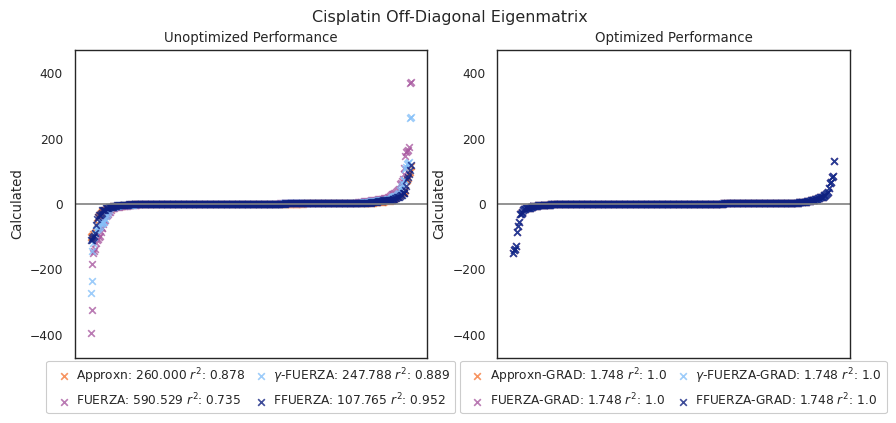

In [9]:
def off_diag_scatter(score_matrices:list, total_scores:list, title:str=''):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle('Cisplatin Off-Diagonal Eigenmatrix'+title)
    palette = itertools.cycle(zesty_palette)
    palette_opt = itertools.cycle(zesty_palette)
    max_y = 0.

    for i, run in enumerate(score_matrices):
        off_diag = run.loc[run['Reference'] == 0.0000]
        off_diag = off_diag.loc[off_diag['Weight'] != 0.0000]
        off_diag = off_diag.sort_values(by='Calculated', ignore_index=True)

        if any(opt_flag in total_scores[i] for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
            color = next(palette_opt)
            axis=1
        else:
            color = next(palette)
            axis=0
        
        seaborn.regplot(data=off_diag, x=off_diag.index, label=r2_score_labels[i], y='Calculated', marker='x', fit_reg=False, ax=ax[axis], color=color)
        max_y = max(max_y, max(off_diag['Calculated']))

    max_y = max_y + 100
    ax[0].set_ylim(top=max_y, bottom=-max_y)
    ax[1].set_ylim(top=max_y, bottom=-max_y)
    ax[0].set_title('Unoptimized Performance')
    ax[1].set_title('Optimized Performance')
    ax[0].legend(bbox_to_anchor=(0.5, -0.2), loc='lower center', fancybox=True, framealpha=1, ncol=2, columnspacing=0.3, handletextpad=0.)
    ax[1].legend(bbox_to_anchor=(0.5, -0.2), loc='lower center', fancybox=True, framealpha=1, ncol=2, columnspacing=0.3, handletextpad=0.)
    ax[0].axhline(y=0, color='gray')
    ax[1].axhline(y=0, color='gray')
    plt.show()

off_diag_scatter(eigenmatrix_scores, score_sums)

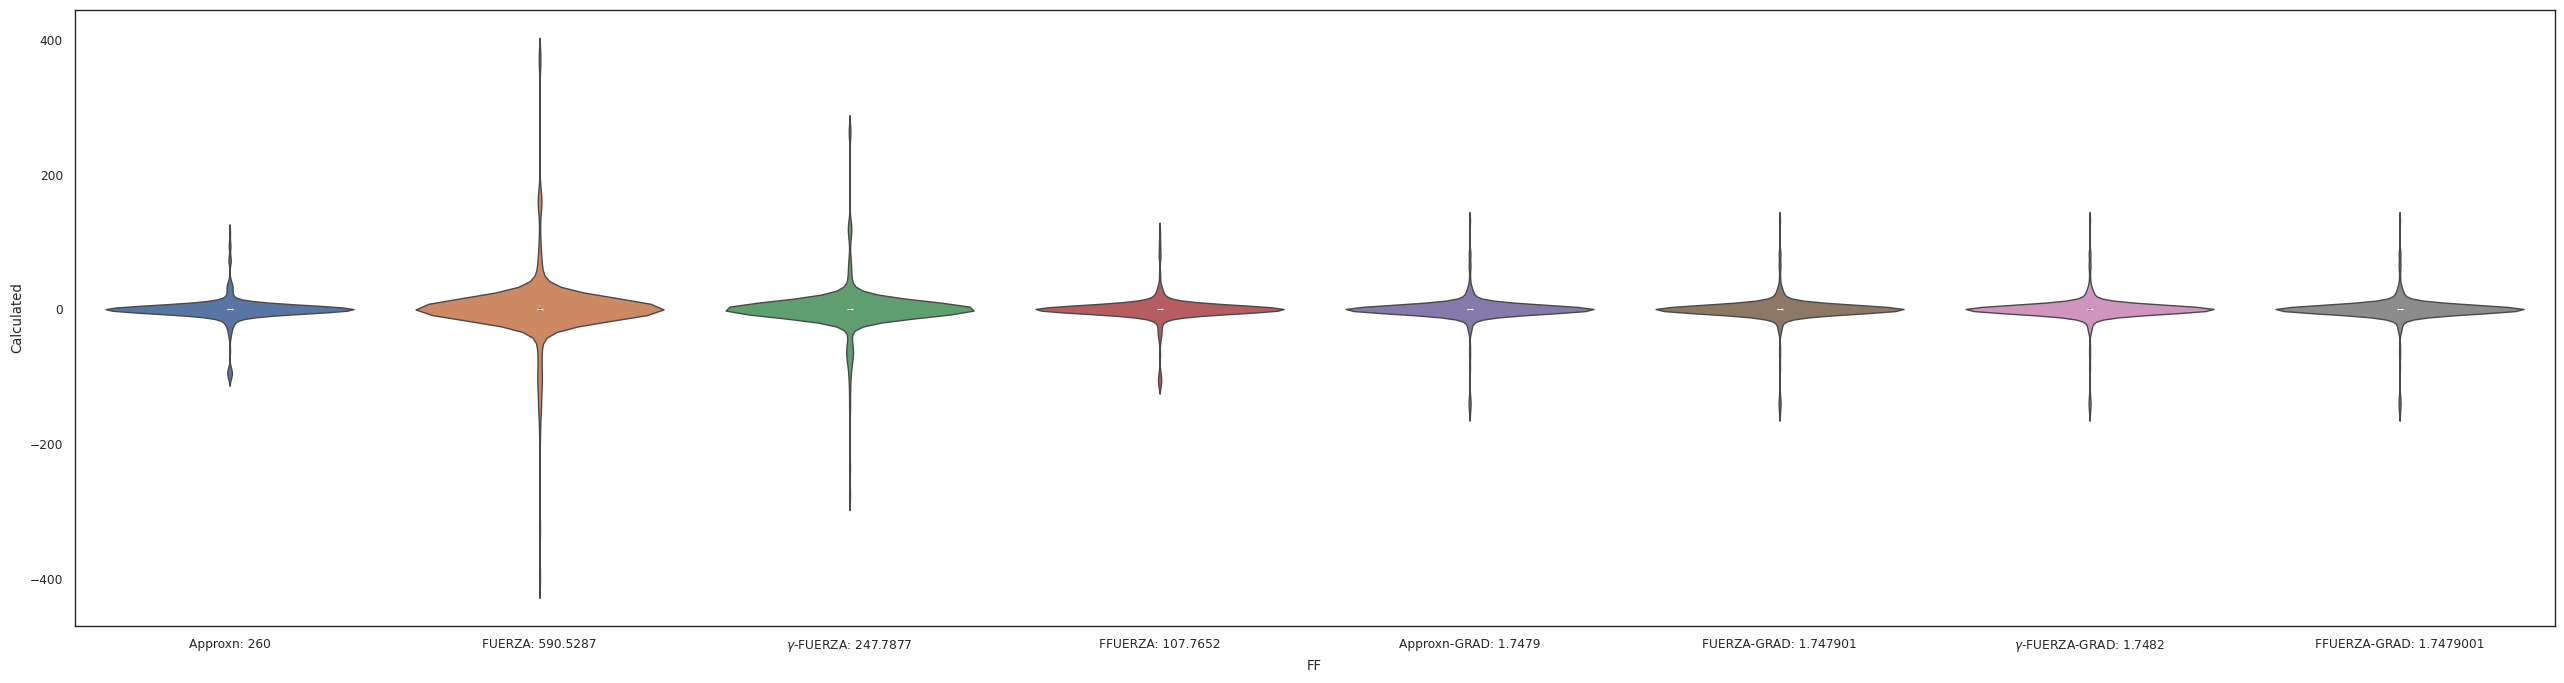

In [10]:
plot_off_diag_violin(static_scores, static_score, eigenmatrix_scores[1:], score_sums[1:])

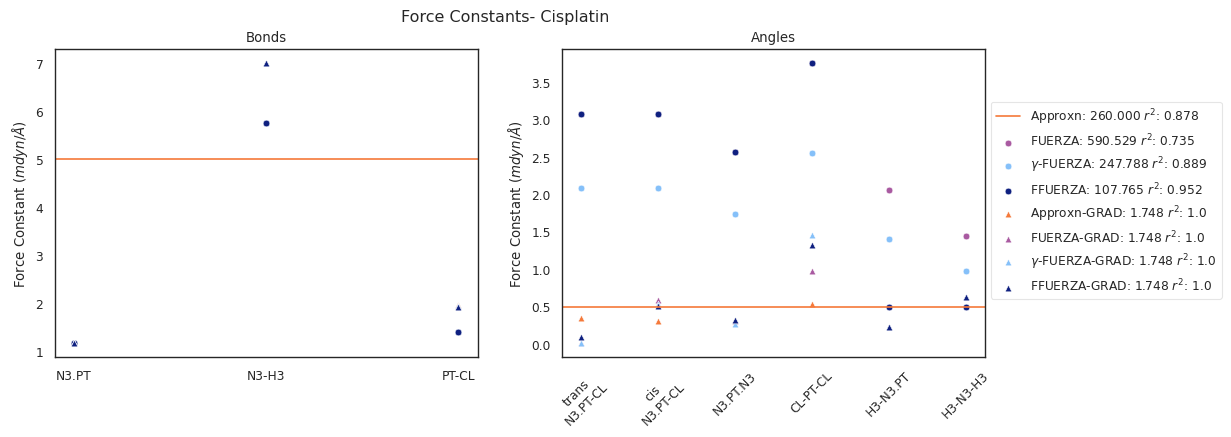

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Bonds'}, ylabel='Force Constant ($mdyn/\\AA$)'>,
        <Axes: title={'center': 'Angles'}, ylabel='Force Constant ($mdyn/\\AA$)'>],
       dtype=object))

In [11]:
plot_ff_params_v_static(bonds, angles, r2_score_labels[1:], bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=r2_score_labels[0], title='- Cisplatin')